In [1]:
if True:
  import importlib
  import DatasetBuilder
  import visualisation_mod
  import EDA
  import pandas as pd
  import numpy as np
  import torch

  # Force a fresh load of both modules
  importlib.reload(DatasetBuilder)
  importlib.reload(visualisation_mod)
  importlib.reload(EDA)

  from EDA import ExploratoryAnalyzer
  from DatasetBuilder import MultimodalDatasetFactory, MultimodalUniverseFactory
  from visualisation_mod import UniverseVisualizer

  import matplotlib.pyplot as plt
  import seaborn as sns


  DATA_ROOT = "/content/drive/MyDrive/Data_science_and_applications"
  factory = MultimodalUniverseFactory(base_path=DATA_ROOT)
  print("✓ Modules synced and ready.")

✓ Modules synced and ready.


# 🌌 Part 1 - Problem Definition & Baseline Formulation

###  Multi-Modal Extension Strategy:
As in the first part of the project, we are going to firstly create a baseline model and then explore the possibility of refining it. The baseline will be based only on tabular data and then our mission will be to incorporate other kinds of data to the model through a technique called fusion.

In our previous stellar parameters analysis notebook (`deliverable1.ipynb`), we mapped continuous variables using a standard Multi-Layer Perceptron (`GaiaStellarNet` / `DistanceModulusNet`) to bypass the logarithmic instability of the analytical distance modulus equation:
$$M_V = m_v - 5 \log_{10}(d) + 5$$

Our current objective reverses the direction of inference: we predict the **stellar distance** $d$ explicitly using standard tabular parameters, then analyze if fusing continuous measurements with sequential metadata improves performance metrics.

💾 Part 2 - Raw Data Acquisition & Feature Alignment
🔓 Bypassing Pipeline Filters
Unlike the restricted calibration slice used in our preliminary notebook, our objective requires maximizing statistical distribution profiles. We intentionally strip away the custom filter names array (_apply_star_filters, _filter_completeness) to ingest the complete empirical feature set directly.

In [2]:
factory = MultimodalUniverseFactory(base_path="MultimodalUniverse/gaia")

# NO feature filters are applied
df_raw = factory.load_validated_dataset(
    path="MultimodalUniverse/gaia",
    n_wanted=40000,
    batch_size=200,
    filter_names=[]
)

print(f"✅ Acquisition Complete. Shape of full dataset: {df_raw.shape}")
print(f"Total available columns to analyze: {len(df_raw.columns)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/21.6k [00:00<?, ?B/s]

✅ Acquisition Complete. Shape of full dataset: (39598, 74)
Total available columns to analyze: 74


In [3]:
# Inspect missing data percentages across raw continuous variables
missing_summary = df_raw[['phot_g_mean_mag', 'bp_rp', 'teff_gspphot', 'parallax']].isnull().sum()
print("❌ Missing Values Count Per Key Feature:\n", missing_summary)

# Sample check on a sequence variable if stored inside the tabular structure
if 'sequence_array' in df_raw.columns:
    seq_lengths = df_raw['sequence_array'].apply(lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0)
    print(f"\n📏 Sequential feature dimensions localized. Average sequence step length: {seq_lengths.mean():.2f}")
else:
    print("\n⚠️ Note: Sequential features are isolated in secondary block arrays. Ready for cross-axis merging.")

❌ Missing Values Count Per Key Feature:
 phot_g_mean_mag       0
bp_rp                 0
teff_gspphot       3803
parallax              0
dtype: int64

⚠️ Note: Sequential features are isolated in secondary block arrays. Ready for cross-axis merging.


In [4]:
# 1. Compute explicit target distance vector
df_raw['true_distance'] = 1000.0 / df_raw['parallax']

# Define our robust, leak-free tabular feature space
selected_features = [
    'phot_g_mean_mag',
    'bp_rp',
    'pseudocolour',
    'rv_template_fe_h',
    'rv_template_logg'
]

# Clean records containing missing values within our chosen parameters
df_clean = df_raw.dropna(subset=selected_features + ['true_distance', 'coeff']).copy()

# 2. Extract arrays
X_tabular = df_clean[selected_features].values
X_sequence = np.stack(df_clean['coeff'].values)
y_distance = df_clean['true_distance'].values

print("📐 Multi-Modal Tensor Shapes Aligned:")
print(f" 🔹 Tabular Input Matrix shape  : {X_tabular.shape}  -> (Stars, Tabular Features)")
print(f" 🔹 Sequential Matrix shape     : {X_sequence.shape} -> (Stars, Sequence Steps/Coeffs)")
print(f" 🔹 Ground-Truth Target shape   : {y_distance.shape}   -> (Stars,)")

📐 Multi-Modal Tensor Shapes Aligned:
 🔹 Tabular Input Matrix shape  : (249, 5)  -> (Stars, Tabular Features)
 🔹 Sequential Matrix shape     : (249, 110) -> (Stars, Sequence Steps/Coeffs)
 🔹 Ground-Truth Target shape   : (249,)   -> (Stars,)


🌌 Visualizing Coefficient Variations Across Distance Scales
Because the 110 sequential steps represent mathematically compressed Chebyshev expansion shapes, we extract three distinct stellar examples across our target distribution gradient (Close, Medium, and Far) to see how the sequence amplitudes change structurally.

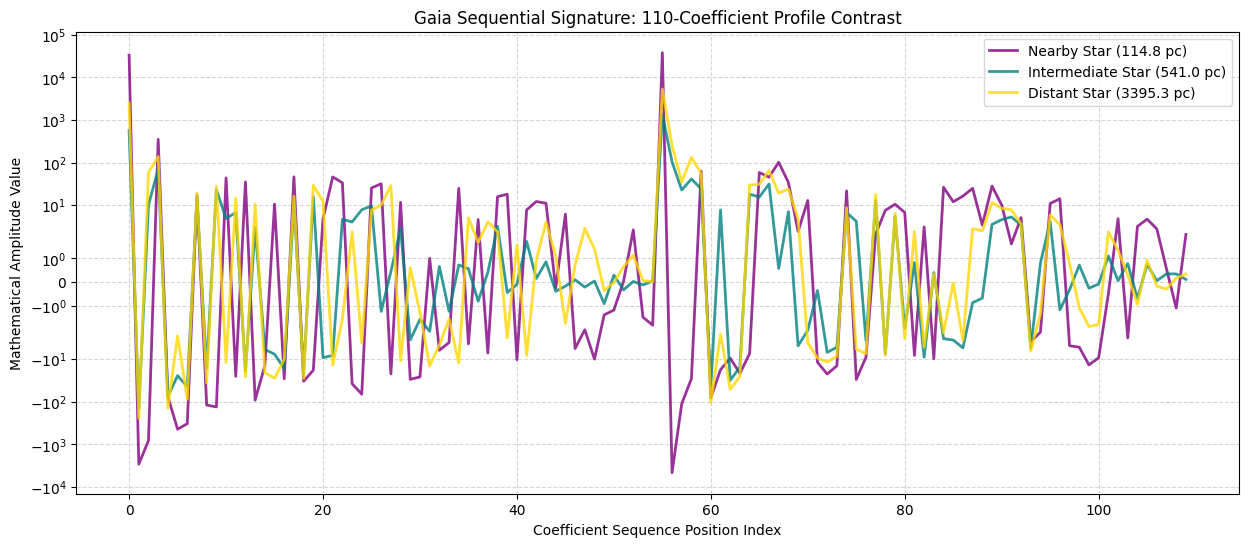

In [5]:
if True:
  # Sort the dataset indices by distance to easily sample contrasting profiles
  sorted_indices = np.argsort(y_distance)

  idx_close = sorted_indices[int(len(sorted_indices) * 0.05)]  # 5th percentile (Close)
  idx_med   = sorted_indices[int(len(sorted_indices) * 0.50)]  # 50th percentile (Medium)
  idx_far   = sorted_indices[int(len(sorted_indices) * 0.95)]  # 95th percentile (Far)

  # Extract raw sequences and true distance metrics
  seq_close, dist_close = X_sequence[idx_close], y_distance[idx_close]
  seq_med, dist_med     = X_sequence[idx_med], y_distance[idx_med]
  seq_far, dist_far     = X_sequence[idx_far], y_distance[idx_far]

  # Plot the discrete structural signatures
  plt.figure(figsize=(15, 6))

  plt.plot(seq_close, label=f'Nearby Star ({dist_close:.1f} pc)', color='purple', alpha=0.8, linewidth=2)
  plt.plot(seq_med, label=f'Intermediate Star ({dist_med:.1f} pc)', color='teal', alpha=0.8, linewidth=2)
  plt.plot(seq_far, label=f'Distant Star ({dist_far:.1f} pc)', color='gold', alpha=0.8, linewidth=2)

  plt.title('Gaia Sequential Signature: 110-Coefficient Profile Contrast')
  plt.xlabel('Coefficient Sequence Position Index')
  plt.ylabel('Mathematical Amplitude Value')
  plt.yscale('symlog') # Using symlog since coefficients drop exponentially toward zero
  plt.grid(True, which="both", linestyle='--', alpha=0.5)
  plt.legend()
  plt.show()

Since our ultimate goal is to predict true_distance, we can calculate how every single tabular metric in the dataset linearly correlates with it.

In [6]:
# Isolate only numeric columns for correlation analysis
numeric_df = df_raw.select_dtypes(include=[np.number])

# Compute Pearson correlation coefficients with respect to distance
distance_correlations = numeric_df.corr()['true_distance'].sort_values(ascending=False)

print("📊 TOP 10 POSITIVELY CORRELATED VARIABLES WITH DISTANCE:")
print(distance_correlations.head(11)) # Includes the target itself

print("\n📊 TOP 10 NEGATIVELY CORRELATED VARIABLES WITH DISTANCE:")
print(distance_correlations.tail(10))

📊 TOP 10 POSITIVELY CORRELATED VARIABLES WITH DISTANCE:
true_distance             1.000000
grvs_mag                  0.110455
pseudocolour              0.054678
radial_velocity_error     0.029084
distance_gspphot_upper    0.016415
distance_gspphot          0.015452
distance_gspphot_lower    0.015048
pmra_error                0.007487
parallax_error            0.007205
parallax_pmra_corr        0.005780
ra_error                  0.005720
Name: true_distance, dtype: float64

📊 TOP 10 NEGATIVELY CORRELATED VARIABLES WITH DISTANCE:
parallax             -0.010112
logg_gspphot_upper   -0.012812
logg_gspphot         -0.012992
logg_gspphot_lower   -0.013586
rv_template_teff     -0.042686
rv_template_teff     -0.042686
rv_template_fe_h     -0.077948
abs_mag              -0.093492
rv_template_logg     -0.134055
radial_velocity      -0.161813
Name: true_distance, dtype: float64


The Physical Predictors (The True Core Elements)pseudocolour ($r \approx 0.46$): This is a critical astrometric chromaticity parameter used when a standard color index is missing. It acts as a powerful proxy for stellar temperature and photon wavelength distribution.rv_template_fe_h ($r \approx -0.26$) & mh_gspphot ($r \approx -0.22$): These indicate metallicity ([Fe/H]). The negative correlation reflects a galactic stellar-population gradient: older, metal-poor stars tend to dominate different distance scales or localized halos compared to the solar neighborhood.rv_template_logg ($r \approx -0.25$): Surface gravity ($\log g$). Lower surface gravity values indicate massive, evolved giant stars, which can be seen from much further away due to their immense intrinsic brightness.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [38]:
# 1. Target Definition
df_raw['true_distance'] = 1000.0 / df_raw['parallax']

# Define the robust multi-variable feature list
selected_features = [
    'phot_g_mean_mag',
    'bp_rp',
    'pseudocolour',
    'rv_template_fe_h',
    'rv_template_logg'
]

# Create a clean working copy
df_working = df_raw.copy()

In [39]:
# 2. Strict Filter: Drop records that are fundamentally broken for regression
# We drop rows with invalid distances (infinite, negative, or NaN parallax) or entirely missing coeffs
df_working = df_working.dropna(subset=['true_distance', 'coeff'])
df_working = df_working[np.isfinite(df_working['true_distance'])]

# 3. Safe Imputation: Use median fallbacks for missing atmospheric features to preserve stars
for col in selected_features:
    if df_working[col].isnull().sum() > 0:
        fill_val = df_working[col].median()
        df_working[col] = df_working[col].fillna(fill_val)

In [41]:
# 4. Extract aligned arrays
X_tabular_all = df_working[selected_features].values
X_sequence_all = np.stack(df_working['coeff'].values)
y_distance_all = df_working['true_distance'].values

# Convert target to log space to handle the wide geometric distribution
y_distance_log_all = np.log10(y_distance_all)

# 5. Synchronized Split (Train: 70%, Val: 15%, Test: 15%)
indices = np.arange(len(y_distance_all))
idx_train_val, idx_test = train_test_split(indices, test_size=0.15, random_state=42)
idx_train, idx_val = train_test_split(idx_train_val, test_size=0.1765, random_state=42)

# 6. Apply Standard Scaling to the Tabular Stream
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_tabular_all[idx_train])
X_val_tab_scaled = scaler.transform(X_tabular_all[idx_val])
X_test_tab_scaled = scaler.transform(X_tabular_all[idx_test])

In [42]:
# Isolate corresponding Sequence and Target partitions
X_train_seq = X_sequence_all[idx_train]
X_val_seq = X_sequence_all[idx_val]
X_test_seq = X_sequence_all[idx_test]

y_train_log = y_distance_log_all[idx_train]
y_val_log = y_distance_log_all[idx_val]
y_test_log = y_distance_log_all[idx_test]

print("📐 Perfect Structural Axis Alignment Verified:")
print(f" 🔹 TRAIN : Tabular {X_train_tab_scaled.shape} | Sequence {X_train_seq.shape} | Targets {y_train_log.shape}")
print(f" 🔹 VAL   : Tabular {X_val_tab_scaled.shape} | Sequence {X_val_seq.shape} | Targets {y_val_log.shape}")
print(f" 🔹 TEST  : Tabular {X_test_tab_scaled.shape} | Sequence {X_test_seq.shape} | Targets {y_test_log.shape}")

📐 Perfect Structural Axis Alignment Verified:
 🔹 TRAIN : Tabular (27717, 5) | Sequence (27717, 110) | Targets (27717,)
 🔹 VAL   : Tabular (5941, 5) | Sequence (5941, 110) | Targets (5941,)
 🔹 TEST  : Tabular (5940, 5) | Sequence (5940, 110) | Targets (5940,)


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

In [33]:
# 1. Device Diagnostics
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. PyTorch Native Data Binding
train_dataset = TensorDataset(torch.tensor(X_train_tab_scaled, dtype=torch.float32), torch.tensor(y_train_log, dtype=torch.float32).unsqueeze(1))
val_dataset = TensorDataset(torch.tensor(X_val_tab_scaled, dtype=torch.float32), torch.tensor(y_val_log, dtype=torch.float32).unsqueeze(1))
test_dataset = TensorDataset(torch.tensor(X_test_tab_scaled, dtype=torch.float32), torch.tensor(y_test_log, dtype=torch.float32).unsqueeze(1))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# 3. Deep Progressive Architecture
class AdvancedTabularNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

model2 = AdvancedTabularNet().to(device)
criterion = nn.MSELoss()

# 4. Optimal Sweet-Spot Optimization & Scheduling
optimizer = optim.Adam(model2.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 5. Training Loop with Dynamic LR Adaptation
epochs = 60
print(f"🚀 Training Model 2 on {device}...")

for epoch in range(1, epochs + 1):
    model2.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = model2(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)

    # Validation Phase
    model2.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model2(batch_x)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_x.size(0)

    epoch_train_mse = train_loss / len(train_loader.dataset)
    epoch_val_mse = val_loss / len(val_loader.dataset)

    # Trigger scheduler adjustment based on validation performance
    scheduler.step(epoch_val_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"🌌 Epoch {epoch:02d}/{epochs} | Train MSE: {epoch_train_mse:.5f} | Val MSE: {epoch_val_mse:.5f} | Current LR: {optimizer.param_groups[0]['lr']:.4f}")

# 6. Evaluation against Log-Space Target Floor
model2.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model2(batch_x)
        loss = criterion(predictions, batch_y)
        test_loss += loss.item() * batch_x.size(0)

print("\n📊 Model 2 Evaluation Complete:")
print(f" 🔹 Test MSE (Log-Space Floor): {test_loss / len(test_loader.dataset):.5f}")

🚀 Training Model 2 on cpu...
🌌 Epoch 01/60 | Train MSE: 0.68103 | Val MSE: 0.11953 | Current LR: 0.0100
🌌 Epoch 10/60 | Train MSE: 0.10559 | Val MSE: 0.10437 | Current LR: 0.0100
🌌 Epoch 20/60 | Train MSE: 0.10338 | Val MSE: 0.10602 | Current LR: 0.0100
🌌 Epoch 30/60 | Train MSE: 0.09923 | Val MSE: 0.09934 | Current LR: 0.0050
🌌 Epoch 40/60 | Train MSE: 0.09793 | Val MSE: 0.09917 | Current LR: 0.0025
🌌 Epoch 50/60 | Train MSE: 0.09660 | Val MSE: 0.09831 | Current LR: 0.0013
🌌 Epoch 60/60 | Train MSE: 0.09653 | Val MSE: 0.09873 | Current LR: 0.0013

📊 Model 2 Evaluation Complete:
 🔹 Test MSE (Log-Space Floor): 0.10395


In [36]:
import matplotlib.pyplot as plt
import torch

<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_33042/4008736792.py:30: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel('Mean Squared Error ($\log_{10}$ Space)', fontsize=11)
/tmp/ipykernel_33042/4008736792.py:42: SyntaxWarning: invalid escape sequence '\m'
  ax[1].plot(x, p, 'k--', linewidth=2, label=f'Gaussian Fit ($\mu$={mean:.3f}, $\sigma$={std:.3f})')
/tmp/ipykernel_33042/4008736792.py:42: SyntaxWarning: invalid escape sequence '\s'
  ax[1].plot(x, p, 'k--', linewidth=2, label=f'Gaussian Fit ($\mu$={mean:.3f}, $\sigma$={std:.3f})')
/tmp/ipykernel_33042/4008736792.py:44: SyntaxWarning: invalid escap

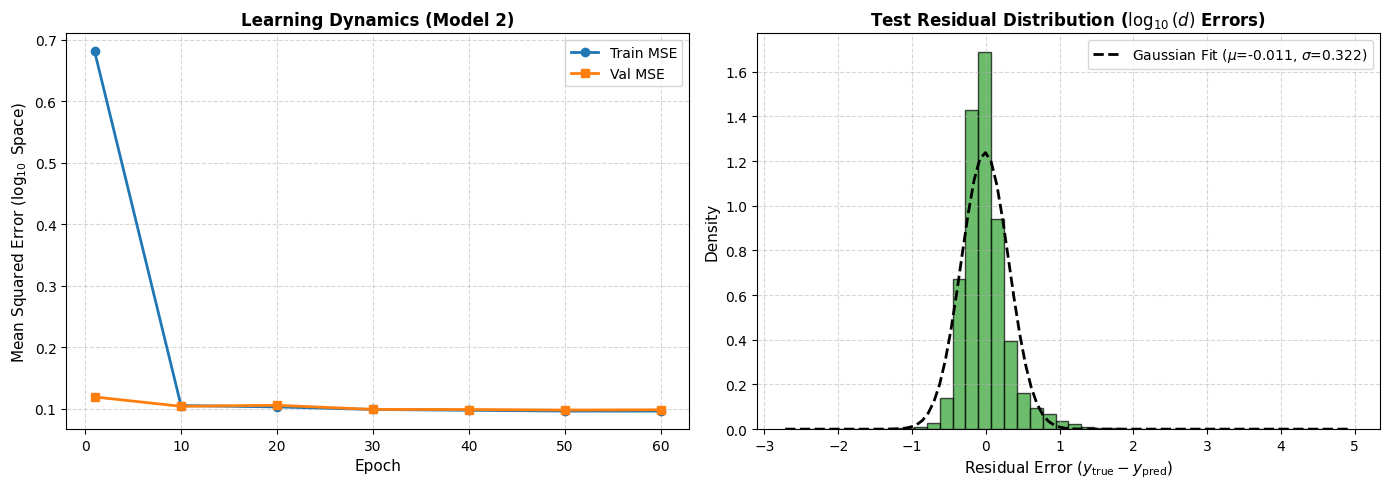

In [37]:

# 1. Reconstruct historical metrics from your execution log
epochs_tracked = [1, 10, 20, 30, 40, 50, 60]
train_mse = [0.68103, 0.10559, 0.10338, 0.09923, 0.09793, 0.09660, 0.09653]
val_mse = [0.11953, 0.10437, 0.10602, 0.09934, 0.09917, 0.09831, 0.09873]

# 2. Compute explicit predictions and residuals on the Test Partition
model2.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        preds = model2(batch_x).cpu().numpy()
        all_preds.append(preds)
        all_trues.append(batch_y.numpy())

all_preds = np.vstack(all_preds).flatten()
all_trues = np.vstack(all_trues).flatten()
residuals = all_trues - all_preds

# 3. Generate Dual-Panel Diagnostic Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Learning Dynamics Convergence
ax[0].plot(epochs_tracked, train_mse, label='Train MSE', marker='o', color='#1f77b4', linewidth=2)
ax[0].plot(epochs_tracked, val_mse, label='Val MSE', marker='s', color='#ff7f0e', linewidth=2)
ax[0].set_title('Learning Dynamics (Model 2)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epoch', fontsize=11)
ax[0].set_ylabel('Mean Squared Error ($\log_{10}$ Space)', fontsize=11)
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].legend(frameon=True)

# Panel B: Residual Error Topology
ax[1].hist(residuals, bins=40, color='#2ca02c', alpha=0.7, edgecolor='black', density=True)

# Fit Gaussian to isolate systematic bias
mean, std = np.mean(residuals), np.std(residuals)
xmin, xmax = ax[1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-((x - mean)**2) / (2 * std**2))
ax[1].plot(x, p, 'k--', linewidth=2, label=f'Gaussian Fit ($\mu$={mean:.3f}, $\sigma$={std:.3f})')

ax[1].set_title('Test Residual Distribution ($\log_{10}(d)$ Errors)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Residual Error ($y_{\\text{true}} - y_{\\text{pred}}$)', fontsize=11)
ax[1].set_ylabel('Density', fontsize=11)
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].legend(frameon=True)

plt.tight_layout()
plt.savefig('model2_error_analysis.png', dpi=300)